In [1]:
!pip install pandas scikit-learn faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 60.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
from faker import Faker
import numpy as np

# Inisialisasi Faker untuk data Indonesia
fake = Faker('id_ID')

# Memuat dataset
# Pastikan sudah mengekstrak 'bank-additional.zip'
try:
    df = pd.read_csv('bank-additional-full.csv', sep=';')
except FileNotFoundError:
    print("Pastikan file 'bank-additional-full.csv' ada di folder yang sama.")
    exit()

print(f"Data asli dimuat, jumlah baris: {len(df)}")
print("Contoh data asli:")
print(df.head())

# Buat data palsu
jumlah_baris = len(df)
nama_palsu = [fake.name() for _ in range(jumlah_baris)]
telp_palsu = [fake.phone_number() for _ in range(jumlah_baris)]

# Buat DataFrame baru untuk data palsu
df_palsu = pd.DataFrame({
    'nama': nama_palsu,
    'no_telp': telp_palsu
})

# Tambahkan ID unik untuk referensi (bukan untuk model)
df['customer_id'] = np.arange(len(df))
df_palsu['customer_id'] = np.arange(len(df))

# df_final adalah data lengkap dengan info nasabah
df_final = pd.merge(df, df_palsu, on='customer_id')

print("\nData setelah digabung dengan info palsu:")
print(df_final[['customer_id', 'nama', 'no_telp', 'age', 'job', 'y']].head())

Data asli dimuat, jumlah baris: 41188
Contoh data asli:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   



In [3]:
# Pisahkan fitur (X) dan target (y)
target_column = 'y'
y = df_final[target_column].map({'yes': 1, 'no': 0})

# SECARA EKSPLISIT HAPUS KOLOM YANG TIDAK DIPERLUKAN UNTUK TRAINING
# 'y' adalah target
# 'duration' adalah bocoran data (data leakage)
# 'customer_id', 'nama', 'no_telp' adalah identifier, bukan fitur prediktif
kolom_yang_dibuang = [target_column, 'duration', 'customer_id', 'nama', 'no_telp']

X = df_final.drop(columns=kolom_yang_dibuang)

print(f"\nFitur yang digunakan untuk melatih model ({len(X.columns)} fitur):")
print(X.columns.tolist())


Fitur yang digunakan untuk melatih model (19 fitur):
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Memisahkan mana kolom numerik dan mana kolom kategorikal
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print("\nFitur Numerik:", numeric_features)
print("\nFitur Kategorikal:", categorical_features)

# 2. Membuat pipeline preprocessing
# Pipeline untuk data numerik: scaling
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline untuk data kategorikal: one-hot encoding
categorical_transformer = Pipeline(steps=[
    # handle_unknown='ignore' akan menangani nilai baru di data tes
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Menggabungkan kedua pipeline dengan ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. Memisahkan data menjadi data training dan data testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y penting untuk dataset yang tidak seimbang (imbalanced) seperti ini


Fitur Numerik: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Fitur Kategorikal: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Buat pipeline lengkap: Preprocessing -> Training Model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42,
                                          n_estimators=100,
                                          class_weight='balanced')) # class_weight 'balanced' membantu data imbalanced
])

# Latih model!
print("\nMulai melatih model (menggunakan RandomForest)...")
model_pipeline.fit(X_train, y_train)
print("Model selesai dilatih.")

# Evaluasi model di data testing
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1] # Probabilitas 'yes'

print(f"\nAkurasi: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f} (Metrik Kunci untuk Ranking)")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))


Mulai melatih model (menggunakan RandomForest)...
Model selesai dilatih.

Akurasi: 0.8957
ROC-AUC Score: 0.7817 (Metrik Kunci untuk Ranking)

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.57      0.29      0.38       928

    accuracy                           0.90      8238
   macro avg       0.74      0.63      0.66      8238
weighted avg       0.88      0.90      0.88      8238



In [6]:
print("\nMenghasilkan skor probabilitas untuk semua nasabah...")

# Gunakan model untuk memprediksi probabilitas pada SEMUA data (X)
# Kolom [:, 1] adalah probabilitas untuk kelas '1' ('yes')
all_probabilities = model_pipeline.predict_proba(X)[:, 1]

# Tambahkan skor ini ke DataFrame 'df_final' kita
df_final['skor_probabilitas'] = all_probabilities

# Tampilkan hasilnya
print(df_final[['customer_id', 'nama', 'no_telp', 'y', 'skor_probabilitas']].head())


Menghasilkan skor probabilitas untuk semua nasabah...
   customer_id                        nama              no_telp   y  \
0            0  Cut Maimunah Waskita, M.Ak       (018) 646 1119  no   
1            1               Laras Lestari    +62 (31) 026 9473  no   
2            2                 Diah Usamah     +62-508-839-8393  no   
3            3               Lidya Rahimah     +62-839-367-7316  no   
4            4                Nova Pertiwi  +62 (0717) 238-1823  no   

   skor_probabilitas  
0               0.00  
1               0.00  
2               0.00  
3               0.00  
4               0.01  


In [7]:
# Siapkan data untuk portal
# Kita hanya butuh nama, no. telp, dan skor
portal_data = df_final[['customer_id', 'nama', 'no_telp', 'skor_probabilitas']]

# URUTKAN (RANKING) berdasarkan skor, dari tertinggi ke terendah
portal_data_prioritas = portal_data.sort_values(by='skor_probabilitas', ascending=False)

# Reset index untuk kebersihan data
portal_data_prioritas = portal_data_prioritas.reset_index(drop=True)

# Tampilkan 10 nasabah prioritas teratas untuk tim sales
print("\n=== DAFTAR NASABAH PRIORITAS UNTUK PORTAL (TOP 10) ===")
print(portal_data_prioritas.head(10))

# Simpan ke CSV untuk di-upload ke database portal Anda
portal_data_prioritas.to_csv('nasabah_prioritas_untuk_portal.csv', index=False)

print("\nSelesai! File 'nasabah_prioritas_untuk_portal.csv' telah dibuat.")


=== DAFTAR NASABAH PRIORITAS UNTUK PORTAL (TOP 10) ===
   customer_id                            nama              no_telp  \
0        40574                Dirja Firgantoro           0852213807   
1        40419  drg. Prasetyo Kusmawati, M.TI.           0827725007   
2        40675            Tina Melani, S.I.Kom      (0182) 231-6586   
3        40653                   Rahmi Siregar    +62 (22) 643-1778   
4        40645       Dr. Elvin Kusmawati, S.E.      +62-62-546-7330   
5        40416                     Ade Permata     +62-243-825-7744   
6        40663                    Alika Wibowo  +62 (0657) 107-8245   
7        39215                  Vanya Yulianti   +62 (021) 755-8226   
8        39220                 R. Sabri Irawan   +62 (083) 825 1943   
9        39640    Salsabila Kusmawati, S.I.Kom   +62 (030) 648-3376   

   skor_probabilitas  
0                1.0  
1                1.0  
2                1.0  
3                1.0  
4                1.0  
5                1.0  
6

<Figure size 800x600 with 0 Axes>

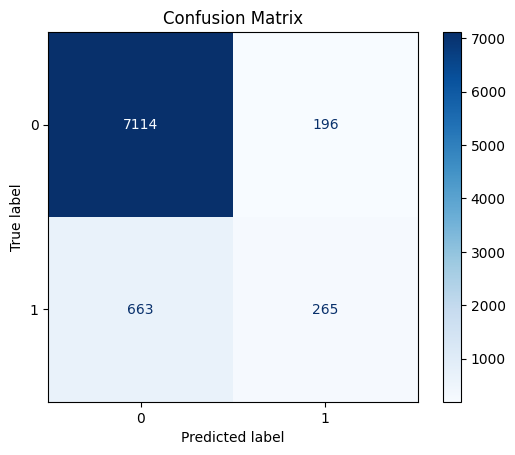

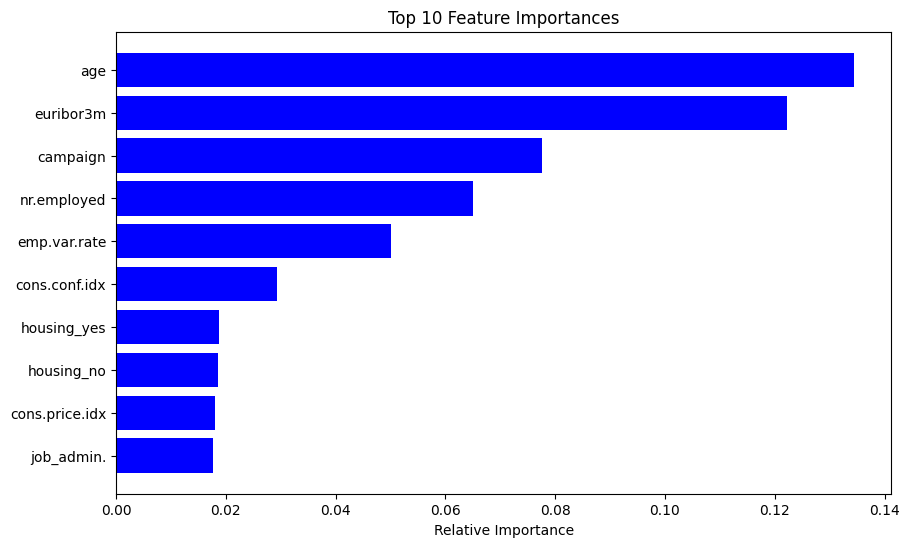

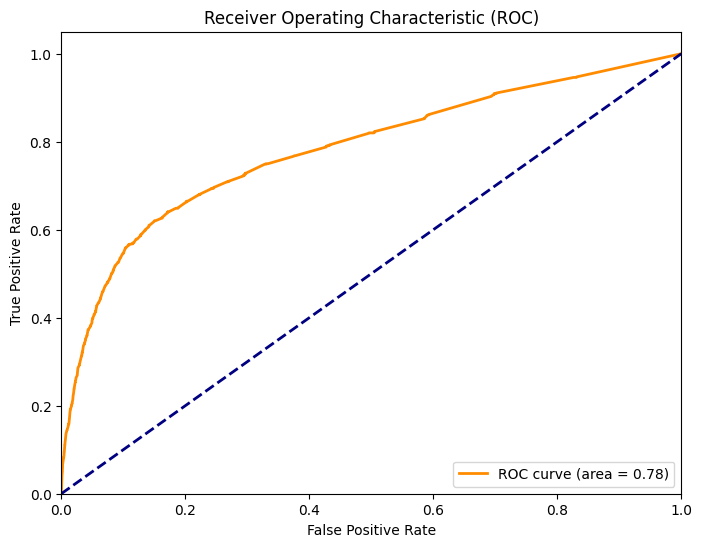

In [8]:
#Visualisasi Data

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# 1. Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(model_pipeline, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png') # Simpan gambar
plt.show()

# 2. Visualisasi Feature Importance (Fitur mana yang paling ngaruh?)
# Mengambil nama fitur setelah One-Hot Encoding
feature_names = (numeric_features +
                 list(model_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_features)))

importances = model_pipeline.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[-10:] # Ambil Top 10

plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.savefig('feature_importance.png') # Simpan gambar
plt.show()

# 3. Visualisasi ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png') # Simpan gambar
plt.show()